# E. coli essentiality: FBA × literature × STRING

Flagship question: for genes in iML1515 (Monk et al. 2017), do flux-balance
knockouts, PEC experimental essentiality, and STRING interaction degree
agree — and when they don't, does Cradle say why?

Uses only `cradle.lab`. GEARS and DepMap are **not** the third layer:
they are human datasets. See `models/ecoli_flagship/REPORT.md`.

In [1]:
from pathlib import Path
from IPython.display import Image, Markdown, display
from cradle import lab

RESULTS = Path("../models/ecoli_flagship/results.json")
REPORT = Path("../models/ecoli_flagship/REPORT.md")
FIGURE = Path("../models/ecoli_flagship/essentiality.png")
print("lab essentiality entry points:", [name for name in dir(lab) if "essential" in name.lower() or name.startswith("fba_") or name.startswith("fetch_")])
print("results exist:", RESULTS.exists())

lab essentiality entry points: ['compare_essentiality', 'essentiality', 'fba_gene_table', 'fba_knockout', 'fba_single_gene_deletion', 'fetch_pec_essentiality', 'fetch_string_degrees', 'fetch_uniprot_essentiality', 'plot_essentiality', 'run_ecoli_essentiality_flagship', 'write_essentiality_report']
results exist: True


## 1. Load the published comparison

`scripts/ecoli_essentiality/run_flagship.py` already ran genome-wide
single-gene deletion (one COBRApy subprocess), PEC `PECData.dat`, and
STRING v12 taxon 511145. Re-solving 1,516 LPs inside the notebook would
not change the science.

In [2]:
import json
payload = json.loads(RESULTS.read_text())
cmp = payload["comparison"]
print("model:", payload["model_curie"])
print("WT growth /h:", round(cmp["baseline_growth"], 4))
print("genes:", cmp["n_model_genes"], "UniProt-labeled:", cmp["n_labeled"])
print("FBA vs UniProt:", cmp["fba_vs_literature"]["metrics"])
print("STRING vs PEC AUROC:", cmp["string_vs_literature"]["auroc"])
print("STRING vs PEC MCC:", cmp["string_vs_literature"]["metrics"]["mcc"])

model: bigg.model:iML1515
WT growth /h: 0.877
genes: 1516 UniProt-labeled: 1515
FBA vs UniProt: {'n': 1515.0, 'precision': 0.47692307692307695, 'recall': 0.7815126050420168, 'f1': 0.5923566878980892, 'accuracy': 0.9155115511551155, 'mcc': 0.5691399897603667}
STRING vs PEC AUROC: 0.6333265013322402
STRING vs PEC MCC: 0.10746161605484214


## 2. Known-gene spot checks, including folA/folM

In [3]:
for item in cmp["known_genes"]:
    obs = item["observed"] or {}
    print(
        f"{item['name']:5} {item['id']}  "
        f"FBA expected={item['fba_expected']:13} observed_essential={obs.get('fba_essential')}  "
        f"lit expected={item['literature_essential']} observed={obs.get('literature_essential')}  "
        f"growth={obs.get('fba_growth')}"
    )

murA  b3189  FBA expected=essential     observed_essential=True  lit expected=True observed=True  growth=2.9044203843129533e-16
accA  b0185  FBA expected=essential     observed_essential=True  lit expected=True observed=True  growth=-1.2023677115050504e-15
lacZ  b0344  FBA expected=nonessential  observed_essential=False  lit expected=False observed=False  growth=0.8769972144269803
lacY  b0343  FBA expected=nonessential  observed_essential=False  lit expected=False observed=False  growth=0.8769972144269774
araA  b0062  FBA expected=nonessential  observed_essential=False  lit expected=False observed=False  growth=0.8769972144269822
folA  b0048  FBA expected=nonessential  observed_essential=False  lit expected=True observed=True  growth=0.8769972144269593


## 3. Cheap live checks

The cobrapy adapter still answers individual knockouts the way
`tests/test_genome_scale_fba.py` does.

In [4]:
wt = lab.fba_knockout([])["objective_value"]
murA = lab.fba_knockout(["b3189"])["objective_value"]
folA = lab.fba_knockout(["b0048"])["objective_value"]
print(f"WT={wt:.4f}  murA KO={murA:.4e}  folA KO={folA:.4f}")
assert murA < 1e-6
assert abs(folA - wt) < 1e-6

WT=0.8770  murA KO=0.0000e+00  folA KO=0.8770


## 4. Figure and report

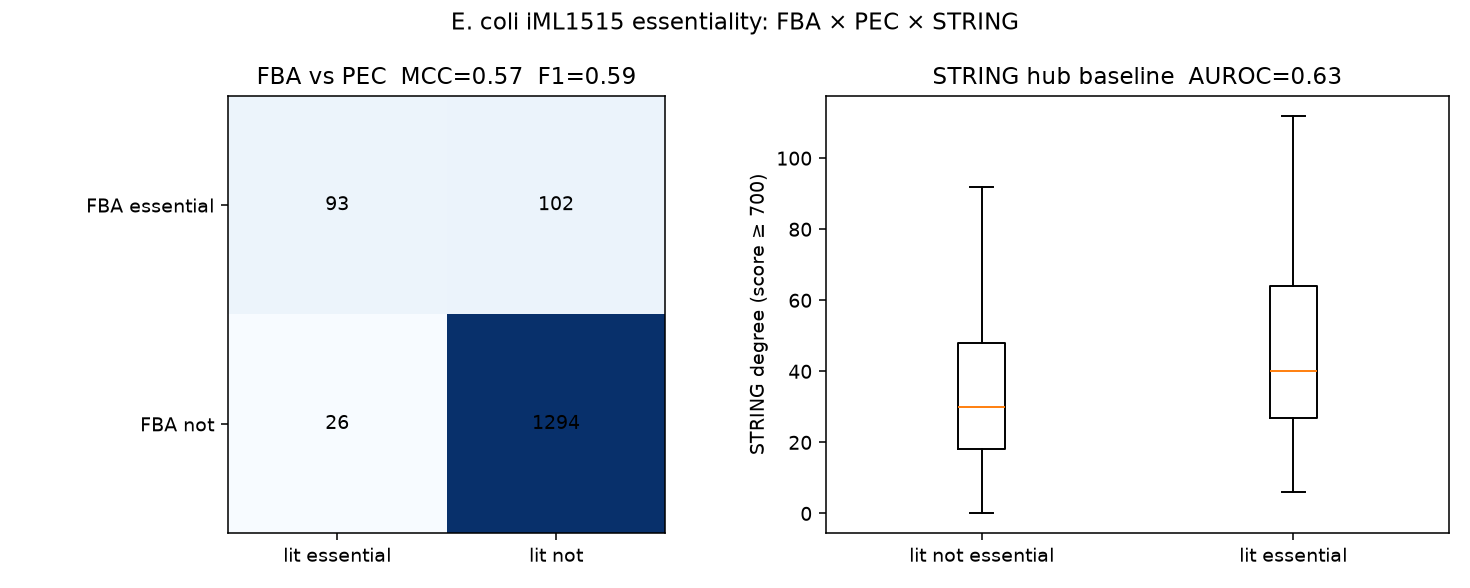

# E. coli essentiality: FBA × PEC × STRING

- **Model:** `bigg.model:iML1515` (Monk et al. 2017, PMID 29020004)
- **Generated:** 2026-09-13T10:53:10.958193+00:00
- **FBA condition:** iML1515 default (aerobic glucose minimal), WT growth 0.8770 /h
- **FBA essential cutoff:** growth < 0.01 × WT
- **Literature:** PEC (Profiling of E. coli Chromosome) — PEC class is knockout-viability / Keio-class genetics (rich media), not a glucose-M9 screen. iML1515 FBA is aerobic glucose minimal. UniProt KW-0256 returned zero reviewed E. coli K-12 entries (checked live 2026-09-13), so PEC is the literature layer.
- **Network baseline:** STRING v12.0 taxon 511145, combined_score ≥ 700 — The registered string DataConnector defaults to human (9606). This baseline uses STRING bulk files for taxon 511145 instead.

## Why GEARS / DepMap are not the third layer

GEARS is trained on Norman et al. 2019 **human K562** Perturb-seq.
DepMap Achilles is **human cancer-line** fitness and is license-gated against
AI-training use. Neither is an E. coli essentiality predictor. STRING
taxon 511145 is the same strain as iML1515.

## Counts

- iML1515 genes: 1516
- PEC-labeled genes in the model: 1515
- FBA-essential: 196
- PEC-essential in the model: 119

## FBA vs PEC

- n=1515  precision=0.477  recall=0.782  F1=0.592  accuracy=0.916  MCC=0.569  AUROC=0.867

Confusion: TP=93 FP=102 TN=1294 FN=26

## STRING degree vs PEC

- n=1513  precision=0.106  recall=0.714  F1=0.184  accuracy=0.503  MCC=0.107  AUROC=0.633

Median-degree threshold used only for the binary scores: 30.0

## Known-gene spot checks

| gene | b-number | FBA expected | FBA observed essential | lit expected | lit observed | FBA growth |
|---|---|---|---|---|---|---|
| murA | `b3189` | essential | True | True | True | 2.9044203843129533e-16 |
| accA | `b0185` | essential | True | True | True | -1.2023677115050504e-15 |
| lacZ | `b0344` | nonessential | False | False | False | 0.8769972144269803 |
| lacY | `b0343` | nonessential | False | False | False | 0.8769972144269774 |
| araA | `b0062` | nonessential | False | False | False | 0.8769972144269822 |
| folA | `b0048` | nonessential | False | True | True | 0.8769972144269593 |

`folA` (b0048) is the documented isozyme rescue: literature-essential DHFR,
non-lethal in iML1515 because the GPR is `b1606 or b0048` (`folM`).



FBA-only disagreements: 102
literature-only disagreements: 26
first five literature-only (includes folA if UniProt agrees):
  {'gene_id': 'b3640', 'name': 'dut', 'fba_growth': 0.8769972144269726}
  {'gene_id': 'b2234', 'name': 'nrdA', 'fba_growth': 0.8769972144269919}
  {'gene_id': 'b0171', 'name': 'pyrH', 'fba_growth': 0.8769972144269802}
  {'gene_id': 'b0954', 'name': 'fabA', 'fba_growth': 0.8769972144269893}
  {'gene_id': 'b4041', 'name': 'plsB', 'fba_growth': 0.876997214426881}


In [5]:
display(Image(filename=str(FIGURE)))
display(Markdown(REPORT.read_text().split("## Disagreements")[0]))
print("FBA-only disagreements:", len(cmp["disagreements"]["fba_essential_literature_not"]))
print("literature-only disagreements:", len(cmp["disagreements"]["literature_essential_fba_not"]))
print("first five literature-only (includes folA if UniProt agrees):")
for row in cmp["disagreements"]["literature_essential_fba_not"][:5]:
    print(" ", row)